# Gamblock-AI Hybrid Detection Model

Cakupan yang dipenuhi:
1. Preprocessing data  
2. Ekstraksi fitur Bag-of-Words (BoW)  
3. Ekstraksi fitur URL  
4. Implementasi Rule-Based System  
5. Pelatihan Logistic Regression  
6. Pengembangan model AI hibrida  
7. Penggabungan fitur URL dan DOM/content  
8. Evaluasi model  
9. Konversi model ke format on-device ONNX  
10. Pengecekan ukuran model < 5 MB  
11. Finalisasi hyperparameter tuning  
12. Penyiapan file model untuk developer  
13. Panduan pendampingan integrasi model ke aplikasi

## 1. Import Library dan Setup Folder

Bagian ini memanggil library yang dibutuhkan dan membuat folder penyimpanan dataset, model, dan laporan.

In [1]:
# Import library utama
import re
import os
import json
import joblib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tldextract
import validators

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.base import clone

warnings.filterwarnings("ignore")

In [2]:
# Setup folder
BASE_DIR = Path(".")
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# File dataset.
# Notebook akan mencari file di data/raw terlebih dahulu.
# Jika tidak ada, notebook akan mencari di folder notebook.
JUDI_FILE = RAW_DIR / "judi.csv"
NON_JUDI_FILE = RAW_DIR / "non_judi.csv"

if not JUDI_FILE.exists():
    JUDI_FILE = BASE_DIR / "judi.csv"

if not NON_JUDI_FILE.exists():
    NON_JUDI_FILE = BASE_DIR / "non_judi.csv"

# Parameter awal hybrid
# Parameter ini masih bisa berubah setelah proses hyperparameter tuning.
ML_WEIGHT = 0.70
RULE_WEIGHT = 0.30
HYBRID_THRESHOLD = 0.50

RANDOM_STATE = 42

print("Path dataset judi    :", JUDI_FILE)
print("Path dataset non-judi:", NON_JUDI_FILE)

Path dataset judi    : data\raw\judi.csv
Path dataset non-judi: data\raw\non_judi.csv


## 2. Load Dataset dan Pelabelan Data

Bagian ini memuat dataset judi dan non-judi, lalu memberi label:
- `1` = judi
- `0` = non-judi

In [3]:
# Load dataset
judi_df = pd.read_csv(JUDI_FILE)
non_judi_df = pd.read_csv(NON_JUDI_FILE)

# Pelabelan dataset
judi_df["label"] = 1
judi_df["label_name"] = "judi"

non_judi_df["label"] = 0
non_judi_df["label_name"] = "non_judi"

# Gabungkan dataset
df = pd.concat([judi_df, non_judi_df], ignore_index=True)

print("Jumlah data judi     :", len(judi_df))
print("Jumlah data non-judi :", len(non_judi_df))
print("Total dataset        :", len(df))
print()
print(df["label_name"].value_counts())

df.head()

Jumlah data judi     : 4184
Jumlah data non-judi : 8780
Total dataset        : 12964

label_name
non_judi    8780
judi        4184
Name: count, dtype: int64


,id,url,title,content,image_path,html_path,label,label_name
0,ID00004,https://117.18.0.168,PARLAY855 * Rekomendasi Situs Bandar Judi Bola...,wowslider.com LIVECHAT WHATSAPP Kami Dari Mana...,dataset_image\1\ID00004.jpg,dataset_html\1\ID00004.html,1,judi
1,ID00005,https://11bolarookie.org,11BOLA: Daftar Bandar Bola Online Slot Deposit...,undefined 11BOLA: Daftar Bandar Bola Online Sl...,dataset_image\1\ID00005.jpg,dataset_html\1\ID00005.html,1,judi
2,ID00020,https://137.184.65.66,MAMI188 🔥 Indonesia Top Quality Game Paling Gacor,REGISTER MASUK VIP LINK TERBARU LOGIN VIP MAMI...,dataset_image\1\ID00020.jpg,dataset_html\1\ID00020.html,1,judi
3,ID00053,https://165.22.53.103,DORAHOKI | Best Gacor Digital Game Agent 2024,LOGIN DORAHOKI DOWNLOAD APK DAFTAR DORAHOKI DO...,dataset_image\1\ID00053.jpg,dataset_html\1\ID00053.html,1,judi
4,ID00056,https://168pretty.top,ATM4D: Login Situs Gaming Online Fleksibel,DAFTAR LOGIN ATM4D: Login Situs Gaming Online ...,dataset_image\1\ID00056.jpg,dataset_html\1\ID00056.html,1,judi


In [4]:
# Cek kolom wajib
required_columns = ["url", "title", "content", "label"]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Kolom wajib tidak ditemukan: {col}")

print("Semua kolom wajib tersedia.")
print(df.columns.tolist())

Semua kolom wajib tersedia.
['id', 'url', 'title', 'content', 'image_path', 'html_path', 'label', 'label_name']


## 3. Preprocessing Data

Bagian ini membersihkan data URL, `title`, dan `content/DOM`.
Kolom `title + content` digabung menjadi `text_clean` agar bisa diproses sebagai fitur teks.

In [5]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Bersihkan data dasar
df = df.dropna(subset=["url"])
df = df.drop_duplicates(subset=["url"]).reset_index(drop=True)

df["url"] = df["url"].fillna("").astype(str)
df["title"] = df["title"].fillna("").astype(str)
df["content"] = df["content"].fillna("").astype(str)

# DOM/content digabung dengan title sebagai fitur teks
df["text_combined"] = df["title"] + " " + df["content"]
df["text_clean"] = df["text_combined"].apply(clean_text)
df["url_clean"] = df["url"].str.lower()

# Hapus baris yang tidak memiliki teks sama sekali
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)

print("Jumlah data setelah preprocessing:", len(df))
df[["url", "title", "text_clean", "label_name"]].head()

Jumlah data setelah preprocessing: 12960


,url,title,text_clean,label_name
0,https://117.18.0.168,PARLAY855 * Rekomendasi Situs Bandar Judi Bola...,parlay855 rekomendasi situs bandar judi bola m...,judi
1,https://11bolarookie.org,11BOLA: Daftar Bandar Bola Online Slot Deposit...,11bola daftar bandar bola online slot deposit ...,judi
2,https://137.184.65.66,MAMI188 🔥 Indonesia Top Quality Game Paling Gacor,mami188 indonesia top quality game paling gaco...,judi
3,https://165.22.53.103,DORAHOKI | Best Gacor Digital Game Agent 2024,dorahoki best gacor digital game agent 2024 lo...,judi
4,https://168pretty.top,ATM4D: Login Situs Gaming Online Fleksibel,atm4d login situs gaming online fleksibel daft...,judi


## 4. Implementasi Rule-Based System

Rule-Based System digunakan untuk menangkap pola/kata kunci judi online yang eksplisit, seperti `slot`, `togel`, `casino`, `jackpot`, dan sebagainya.

In [6]:
GAMBLING_KEYWORDS = [
    "judi", "judol", "slot", "slot online", "togel", "casino", "kasino",
    "poker", "jackpot", "maxwin", "gacor", "rtp", "parlay", "taruhan",
    "betting", "bola88", "sabung ayam", "deposit", "withdraw", "wd",
    "bonus", "freebet", "bandar", "agen", "daftar slot", "login slot",
    "live casino"
]


def normalize_rule_text(text):
    if text is None:
        return ""

    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def count_keyword_matches(text):
    text = normalize_rule_text(text)
    count = 0

    for keyword in GAMBLING_KEYWORDS:
        pattern = r"\b" + re.escape(keyword) + r"\b"
        if re.search(pattern, text):
            count += 1

    return count


def get_rule_score(url="", title="", content=""):
    combined_text = f"{url} {title} {content}"
    keyword_count = count_keyword_matches(combined_text)

    # Skor dibatasi 0 sampai 1
    rule_score = min(keyword_count / 5, 1.0)

    return rule_score


df["rule_score"] = df.apply(
    lambda row: get_rule_score(
        url=row["url"],
        title=row["title"],
        content=row["content"]
    ),
    axis=1
)

df[["url", "title", "rule_score", "label_name"]].head()

,url,title,rule_score,label_name
0,https://117.18.0.168,PARLAY855 * Rekomendasi Situs Bandar Judi Bola...,1.0,judi
1,https://11bolarookie.org,11BOLA: Daftar Bandar Bola Online Slot Deposit...,0.6,judi
2,https://137.184.65.66,MAMI188 🔥 Indonesia Top Quality Game Paling Gacor,0.2,judi
3,https://165.22.53.103,DORAHOKI | Best Gacor Digital Game Agent 2024,0.6,judi
4,https://168pretty.top,ATM4D: Login Situs Gaming Online Fleksibel,0.2,judi


## 5. Ekstraksi Fitur URL

Bagian ini mengambil fitur leksikal URL, seperti panjang URL, jumlah angka, jumlah titik, jumlah slash, keyword mencurigakan, domain, dan subdomain.

In [7]:
SUSPICIOUS_URL_KEYWORDS = [
    "slot", "togel", "casino", "poker", "judi", "judol", "bet",
    "jackpot", "gacor", "rtp", "maxwin", "deposit", "parlay",
    "bandar", "agen"
]

extractor = tldextract.TLDExtract(suffix_list_urls=())


def extract_domain_parts(url):
    try:
        result = extractor(str(url))
        return result.domain, result.suffix, result.subdomain
    except Exception:
        return "", "", ""


def extract_url_features(url):
    if pd.isna(url):
        url = ""

    url = str(url).lower()
    domain, suffix, subdomain = extract_domain_parts(url)

    features = {
        "url_length": len(url),
        "url_digit_count": sum(char.isdigit() for char in url),
        "url_dot_count": url.count("."),
        "url_slash_count": url.count("/"),
        "url_hyphen_count": url.count("-"),
        "url_question_count": url.count("?"),
        "url_equal_count": url.count("="),
        "url_keyword_count": sum(1 for keyword in SUSPICIOUS_URL_KEYWORDS if keyword in url),
        "url_has_number": 1 if re.search(r"\d", url) else 0,
        "url_has_https": 1 if url.startswith("https") else 0,
        "url_is_valid": 1 if validators.url(url) is True else 0,
        "domain_length": len(domain),
        "subdomain_length": len(subdomain),
        "suffix_length": len(suffix),
    }

    return features


URL_FEATURE_COLUMNS = [
    "url_length", "url_digit_count", "url_dot_count", "url_slash_count",
    "url_hyphen_count", "url_question_count", "url_equal_count",
    "url_keyword_count", "url_has_number", "url_has_https",
    "url_is_valid", "domain_length", "subdomain_length", "suffix_length"
]

# Pengaman: hapus fitur URL lama jika cell dijalankan ulang agar kolom tidak dobel
df = df.drop(columns=URL_FEATURE_COLUMNS, errors="ignore")

url_features_df = pd.DataFrame(df["url"].apply(extract_url_features).tolist())
url_features_df.index = df.index

df = pd.concat([df, url_features_df], axis=1)
df = df.loc[:, ~df.columns.duplicated()].copy()

print("Fitur URL:")
print(URL_FEATURE_COLUMNS)

df[["url"] + URL_FEATURE_COLUMNS].head()

Fitur URL:
['url_length', 'url_digit_count', 'url_dot_count', 'url_slash_count', 'url_hyphen_count', 'url_question_count', 'url_equal_count', 'url_keyword_count', 'url_has_number', 'url_has_https', 'url_is_valid', 'domain_length', 'subdomain_length', 'suffix_length']


,url,url_length,url_digit_count,url_dot_count,url_slash_count,url_hyphen_count,url_question_count,url_equal_count,url_keyword_count,url_has_number,url_has_https,url_is_valid,domain_length,subdomain_length,suffix_length
0,https://117.18.0.168,20,9,3,2,0,0,0,0,1,1,1,12,0,0
1,https://11bolarookie.org,24,2,1,2,0,0,0,0,1,1,1,12,0,3
2,https://137.184.65.66,21,10,3,2,0,0,0,0,1,1,1,13,0,0
3,https://165.22.53.103,21,10,3,2,0,0,0,0,1,1,1,13,0,0
4,https://168pretty.top,21,3,1,2,0,0,0,0,1,1,1,9,0,3


In [8]:
# Simpan dataset bersih
clean_dataset_path = PROCESSED_DIR / "dataset_clean.csv"
df.to_csv(clean_dataset_path, index=False)

print("Dataset bersih disimpan di:", clean_dataset_path)

Dataset bersih disimpan di: data\processed\dataset_clean.csv


## 6. Split Train-Test

Dataset dibagi menjadi data latih dan data uji.
Data uji dipakai hanya untuk evaluasi akhir.

In [9]:
X = df[["text_clean"] + URL_FEATURE_COLUMNS]
y = df["label"]

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

X_train = train_df[["text_clean"] + URL_FEATURE_COLUMNS]
y_train = train_df["label"]

X_test = test_df[["text_clean"] + URL_FEATURE_COLUMNS]
y_test = test_df["label"]

train_path = PROCESSED_DIR / "train.csv"
test_path = PROCESSED_DIR / "test.csv"

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print("Train:", len(train_df))
print("Test :", len(test_df))
print()
print("Distribusi train:")
print(train_df["label_name"].value_counts())
print()
print("Distribusi test:")
print(test_df["label_name"].value_counts())

Train: 10368
Test : 2592

Distribusi train:
label_name
non_judi    7021
judi        3347
Name: count, dtype: int64

Distribusi test:
label_name
non_judi    1755
judi         837
Name: count, dtype: int64


## 7. Ekstraksi Fitur BoW dan Pelatihan Logistic Regression

Bagian BoW ada pada `CountVectorizer`.
`CountVectorizer` mengubah teks `text_clean` dari title + content/DOM menjadi fitur numerik.

Logistic Regression digunakan sebagai model machine learning yang ringan untuk on-device AI.

In [10]:
def build_logistic_pipeline(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    C=1.0,
    penalty="l2",
    class_weight="balanced"
):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "text_bow",
                CountVectorizer(
                    max_features=max_features,
                    ngram_range=ngram_range,
                    min_df=min_df
                ),
                "text_clean"
            ),
            (
                "url_features",
                StandardScaler(),
                URL_FEATURE_COLUMNS
            )
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(
                max_iter=1000,
                class_weight=class_weight,
                solver="liblinear",
                penalty=penalty,
                C=C
            ))
        ]
    )

    return model


# Model awal/baseline
baseline_model = build_logistic_pipeline(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    C=1.0,
    penalty="l2",
    class_weight="balanced"
)

baseline_model.fit(X_train, y_train)

print("Baseline Logistic Regression berhasil dilatih.")

Baseline Logistic Regression berhasil dilatih.


## 8. Finalisasi Hyperparameter Tuning

Bagian ini memenuhi poin finalisasi hyperparameter tuning.

Tuning dilakukan pada:
- `max_features` BoW
- `ngram_range` BoW
- `min_df` BoW
- `C` Logistic Regression
- `penalty` Logistic Regression
- `class_weight`

Model final dipilih dengan mempertimbangkan performa dan risiko false positive.

In [11]:
# Validation split untuk memilih konfigurasi terbaik tanpa memakai test set
train_base_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_df["label"]
)

X_train_base = train_base_df[["text_clean"] + URL_FEATURE_COLUMNS]
y_train_base = train_base_df["label"]

X_val = val_df[["text_clean"] + URL_FEATURE_COLUMNS]
y_val = val_df["label"]

print("Train base:", len(train_base_df))
print("Validation:", len(val_df))

Train base: 8294
Validation: 2074


In [12]:
# Pipeline untuk tuning
tuning_pipeline = build_logistic_pipeline()

param_distributions = {
    "preprocessor__text_bow__max_features": [3000, 5000, 7000, 10000],
    "preprocessor__text_bow__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "preprocessor__text_bow__min_df": [1, 2, 3],
    "classifier__C": [0.05, 0.1, 0.5, 1, 2, 5, 10],
    "classifier__penalty": ["l1", "l2"],
    "classifier__class_weight": ["balanced", None]
}

# n_iter bisa dinaikkan ke 40 jika ingin pencarian lebih luas.
random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

random_search.fit(X_train_base, y_train_base)

print("Best parameter Logistic Regression + BoW:")
print(random_search.best_params_)

print("\nBest F1-score CV:")
print(random_search.best_score_)

best_tuned_model = random_search.best_estimator_

# Simpan hasil tuning
tuning_result_df = pd.DataFrame(random_search.cv_results_).sort_values(by="rank_test_score")
tuning_result_path = REPORT_DIR / "hyperparameter_tuning_results.csv"
tuning_result_df.to_csv(tuning_result_path, index=False)

print("Hasil tuning disimpan di:", tuning_result_path)
tuning_result_df[[
    "rank_test_score",
    "mean_test_score",
    "param_preprocessor__text_bow__max_features",
    "param_preprocessor__text_bow__ngram_range",
    "param_preprocessor__text_bow__min_df",
    "param_classifier__C",
    "param_classifier__penalty",
    "param_classifier__class_weight"
]].head()

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameter Logistic Regression + BoW:
{'preprocessor__text_bow__ngram_range': (1, 2), 'preprocessor__text_bow__min_df': 3, 'preprocessor__text_bow__max_features': 10000, 'classifier__penalty': 'l2', 'classifier__class_weight': 'balanced', 'classifier__C': 0.05}

Best F1-score CV:
0.9564966319105866
Hasil tuning disimpan di: reports\hyperparameter_tuning_results.csv


,rank_test_score,mean_test_score,param_preprocessor__text_bow__max_features,param_preprocessor__text_bow__ngram_range,param_preprocessor__text_bow__min_df,param_classifier__C,param_classifier__penalty,param_classifier__class_weight
9,1,0.956497,10000,"(1, 2)",3,0.05,l2,balanced
1,2,0.948768,7000,"(1, 1)",1,2.00,l2,balanced
18,3,0.948757,5000,"(1, 2)",1,0.50,l1,balanced
12,4,0.948682,5000,"(1, 2)",2,5.00,l2,None
16,5,0.948659,7000,"(1, 1)",2,2.00,l2,None


## 9. Pengembangan Model AI Hibrida

Model hybrid menggabungkan:
- probabilitas Logistic Regression
- skor Rule-Based System

Rumus:
`hybrid_score = (ML_WEIGHT * ml_probability) + (RULE_WEIGHT * rule_score)`

In [13]:
def hybrid_predict_dataframe(model, data, ml_weight, rule_weight, threshold):
    X_data = data[["text_clean"] + URL_FEATURE_COLUMNS]

    ml_probability = model.predict_proba(X_data)[:, 1]

    rule_scores = data.apply(
        lambda row: get_rule_score(
            url=row["url"],
            title=row["title"],
            content=row["content"]
        ),
        axis=1
    ).values

    hybrid_scores = (ml_weight * ml_probability) + (rule_weight * rule_scores)
    hybrid_predictions = (hybrid_scores >= threshold).astype(int)

    return hybrid_predictions, hybrid_scores, ml_probability, rule_scores


def evaluate_hybrid(model, data, ml_weight=0.70, threshold=0.50):
    rule_weight = 1 - ml_weight

    y_true = data["label"]
    hybrid_pred, hybrid_score, ml_probability, rule_scores = hybrid_predict_dataframe(
        model=model,
        data=data,
        ml_weight=ml_weight,
        rule_weight=rule_weight,
        threshold=threshold
    )

    tn, fp, fn, tp = confusion_matrix(y_true, hybrid_pred).ravel()

    precision = precision_score(y_true, hybrid_pred, zero_division=0)
    recall = recall_score(y_true, hybrid_pred, zero_division=0)
    f1 = f1_score(y_true, hybrid_pred, zero_division=0)
    accuracy = accuracy_score(y_true, hybrid_pred)

    # Skor seleksi dibuat precision-oriented karena proposal menekankan minimalisasi false positive.
    # F1 tetap menjadi komponen utama, tetapi precision dan false positive rate ikut dipertimbangkan.
    total_non_judi = tn + fp
    false_positive_rate = fp / total_non_judi if total_non_judi > 0 else 0

    selection_score = (0.50 * f1) + (0.30 * precision) + (0.20 * recall) - (0.05 * false_positive_rate)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "false_positive": fp,
        "false_negative": fn,
        "true_negative": tn,
        "true_positive": tp,
        "false_positive_rate": false_positive_rate,
        "selection_score": selection_score,
        "ml_weight": ml_weight,
        "rule_weight": rule_weight,
        "threshold": threshold
    }

In [14]:
# Bandingkan baseline dan tuned model pada validation set
# Baseline untuk validasi dilatih hanya pada train_base agar tidak bocor ke validation.
baseline_val_model = build_logistic_pipeline(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    C=1.0,
    penalty="l2",
    class_weight="balanced"
)
baseline_val_model.fit(X_train_base, y_train_base)

candidate_models = {
    "baseline_default": baseline_val_model,
    "tuned_random_search": best_tuned_model
}

ml_weight_candidates = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85]
threshold_candidates = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65]

hybrid_tuning_results = []

for model_name, candidate_model in candidate_models.items():
    for ml_weight in ml_weight_candidates:
        for threshold in threshold_candidates:
            result = evaluate_hybrid(
                model=candidate_model,
                data=val_df,
                ml_weight=ml_weight,
                threshold=threshold
            )
            result["model_name"] = model_name
            hybrid_tuning_results.append(result)

hybrid_tuning_df = pd.DataFrame(hybrid_tuning_results)

# Pilih konfigurasi final:
# 1) selection_score tertinggi
# 2) jika mirip, pilih precision dan F1 lebih tinggi
# 3) false positive ikut ditekan lewat false_positive_rate pada selection_score
hybrid_tuning_df = hybrid_tuning_df.sort_values(
    by=["selection_score", "precision", "f1_score", "recall"],
    ascending=False
).reset_index(drop=True)

hybrid_tuning_path = REPORT_DIR / "hybrid_weight_threshold_tuning_results.csv"
hybrid_tuning_df.to_csv(hybrid_tuning_path, index=False)

print("Hasil tuning hybrid disimpan di:", hybrid_tuning_path)
hybrid_tuning_df.head(10)

Hasil tuning hybrid disimpan di: reports\hybrid_weight_threshold_tuning_results.csv


,accuracy,precision,recall,f1_score,false_positive,false_negative,true_negative,true_positive,false_positive_rate,selection_score,ml_weight,rule_weight,threshold,model_name
0,0.983124,0.980333,0.967164,0.973704,13,22,1391,648,0.009259,0.973922,0.75,0.25,0.40,tuned_random_search
1,0.983124,0.980333,0.967164,0.973704,13,22,1391,648,0.009259,0.973922,0.80,0.20,0.45,tuned_random_search
2,0.982642,0.980303,0.965672,0.972932,13,23,1391,647,0.009259,0.973228,0.70,0.30,0.40,tuned_random_search
3,0.982642,0.980303,0.965672,0.972932,13,23,1391,647,0.009259,0.973228,0.85,0.15,0.45,tuned_random_search
4,0.982642,0.978852,0.967164,0.972973,14,22,1390,648,0.009972,0.973076,0.80,0.20,0.40,tuned_random_search
5,0.982642,0.974551,0.971642,0.973094,17,19,1387,651,0.012108,0.972635,0.85,0.15,0.40,tuned_random_search
6,0.982160,0.980273,0.964179,0.972160,13,24,1391,646,0.009259,0.972535,0.65,0.35,0.40,tuned_random_search
7,0.982160,0.980273,0.964179,0.972160,13,24,1391,646,0.009259,0.972535,0.75,0.25,0.45,tuned_random_search
8,0.981678,0.980243,0.962687,0.971386,13,25,1391,645,0.009259,0.971840,0.85,0.15,0.50,tuned_random_search
9,0.981196,0.980213,0.961194,0.970610,13,26,1391,644,0.009259,0.971145,0.70,0.30,0.45,tuned_random_search


In [15]:
# Ambil konfigurasi terbaik
best_config = hybrid_tuning_df.iloc[0]

selected_model_name = best_config["model_name"]
ML_WEIGHT = float(best_config["ml_weight"])
RULE_WEIGHT = float(best_config["rule_weight"])
HYBRID_THRESHOLD = float(best_config["threshold"])

print("MODEL FINAL TERPILIH")
print("Model source     :", selected_model_name)
print("ML Weight        :", ML_WEIGHT)
print("Rule Weight      :", RULE_WEIGHT)
print("Hybrid Threshold :", HYBRID_THRESHOLD)
print("Validation F1    :", round(float(best_config["f1_score"]), 4))
print("Validation Prec. :", round(float(best_config["precision"]), 4))
print("Validation Recall:", round(float(best_config["recall"]), 4))
print("Validation FP    :", int(best_config["false_positive"]))
print("Validation FN    :", int(best_config["false_negative"]))

MODEL FINAL TERPILIH
Model source     : tuned_random_search
ML Weight        : 0.75
Rule Weight      : 0.25
Hybrid Threshold : 0.4
Validation F1    : 0.9737
Validation Prec. : 0.9803
Validation Recall: 0.9672
Validation FP    : 13
Validation FN    : 22


In [16]:
# Latih ulang model final menggunakan seluruh data train.
# Jika baseline_default yang terpilih, gunakan parameter baseline.
# Jika tuned_random_search yang terpilih, gunakan parameter hasil tuning.
if selected_model_name == "baseline_default":
    logistic_model = build_logistic_pipeline(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=1,
        C=1.0,
        penalty="l2",
        class_weight="balanced"
    )
else:
    logistic_model = clone(best_tuned_model)

logistic_model.fit(X_train, y_train)

print("Model final berhasil dilatih ulang dengan seluruh data train.")

Model final berhasil dilatih ulang dengan seluruh data train.


## 10. Evaluasi Logistic Regression

Evaluasi ini hanya untuk model Logistic Regression tanpa Rule-Based.

In [17]:
ml_pred = logistic_model.predict(X_test)
ml_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Evaluasi Logistic Regression:")
print("Accuracy :", accuracy_score(y_test, ml_pred))
print("Precision:", precision_score(y_test, ml_pred, zero_division=0))
print("Recall   :", recall_score(y_test, ml_pred, zero_division=0))
print("F1-Score :", f1_score(y_test, ml_pred, zero_division=0))
print()
print(classification_report(y_test, ml_pred, target_names=["non_judi", "judi"], zero_division=0))

Evaluasi Logistic Regression:
Accuracy : 0.9722222222222222
Precision: 0.9613992762364294
Recall   : 0.9522102747909199
F1-Score : 0.9567827130852341

              precision    recall  f1-score   support

    non_judi       0.98      0.98      0.98      1755
        judi       0.96      0.95      0.96       837

    accuracy                           0.97      2592
   macro avg       0.97      0.97      0.97      2592
weighted avg       0.97      0.97      0.97      2592



## 11. Evaluasi Model Hybrid

Bagian ini mengevaluasi model final hybrid menggunakan Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix.

In [18]:
hybrid_pred, hybrid_score, ml_probability, rule_scores = hybrid_predict_dataframe(
    model=logistic_model,
    data=test_df,
    ml_weight=ML_WEIGHT,
    rule_weight=RULE_WEIGHT,
    threshold=HYBRID_THRESHOLD
)

hybrid_accuracy = accuracy_score(y_test, hybrid_pred)
hybrid_precision = precision_score(y_test, hybrid_pred, zero_division=0)
hybrid_recall = recall_score(y_test, hybrid_pred, zero_division=0)
hybrid_f1 = f1_score(y_test, hybrid_pred, zero_division=0)

print("HASIL EVALUASI HYBRID MODEL GAMBLOCK-AI")
print("--------------------------------------")
print("Metode       : Rule-Based System + Logistic Regression")
print("Model source :", selected_model_name)
print("ML Weight    :", ML_WEIGHT)
print("Rule Weight  :", RULE_WEIGHT)
print("Threshold    :", HYBRID_THRESHOLD)
print()
print("Accuracy     :", round(hybrid_accuracy, 4))
print("Precision    :", round(hybrid_precision, 4))
print("Recall       :", round(hybrid_recall, 4))
print("F1-Score     :", round(hybrid_f1, 4))
print()
print(classification_report(y_test, hybrid_pred, target_names=["non_judi", "judi"], zero_division=0))

HASIL EVALUASI HYBRID MODEL GAMBLOCK-AI
--------------------------------------
Metode       : Rule-Based System + Logistic Regression
Model source : tuned_random_search
ML Weight    : 0.75
Rule Weight  : 0.25
Threshold    : 0.4

Accuracy     : 0.9738
Precision    : 0.9638
Recall       : 0.9546
F1-Score     : 0.9592

              precision    recall  f1-score   support

    non_judi       0.98      0.98      0.98      1755
        judi       0.96      0.95      0.96       837

    accuracy                           0.97      2592
   macro avg       0.97      0.97      0.97      2592
weighted avg       0.97      0.97      0.97      2592



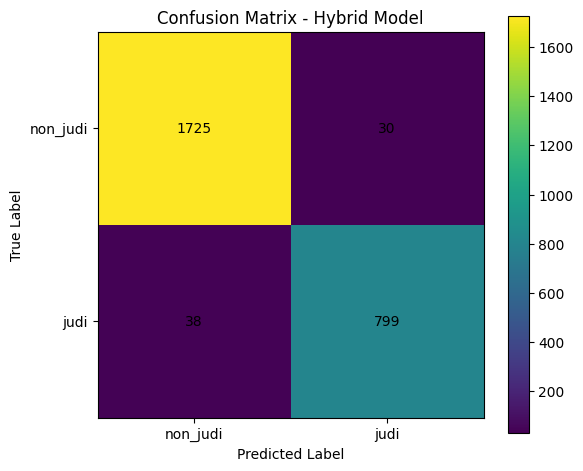

Confusion matrix disimpan di: reports\confusion_matrix_hybrid.png


In [19]:
cm = confusion_matrix(y_test, hybrid_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Hybrid Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["non_judi", "judi"])
plt.yticks([0, 1], ["non_judi", "judi"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()

confusion_matrix_path = REPORT_DIR / "confusion_matrix_hybrid.png"
plt.savefig(confusion_matrix_path, dpi=300)
plt.show()

print("Confusion matrix disimpan di:", confusion_matrix_path)

In [20]:
# Simpan hasil prediksi test
result_df = test_df.copy()
result_df["ml_probability_judi"] = ml_probability
result_df["rule_score"] = rule_scores
result_df["hybrid_score"] = hybrid_score
result_df["prediction"] = hybrid_pred
result_df["prediction_label"] = result_df["prediction"].map({
    0: "non_judi",
    1: "judi"
})

prediction_result_path = REPORT_DIR / "hybrid_prediction_result.csv"
result_df.to_csv(prediction_result_path, index=False)

result_df[[
    "url",
    "title",
    "label_name",
    "ml_probability_judi",
    "rule_score",
    "hybrid_score",
    "prediction_label"
]].head(10)

,url,title,label_name,ml_probability_judi,rule_score,hybrid_score,prediction_label
1913,https://www.herovictory4dp.com/wap/register.ht...,Pendaftaran user baru | Victory 4DP,judi,0.992669,0.0,0.744502,judi
5244,https://jba.co.id,Balai Lelang Otomotif Indonesia | JBA Indonesia,non_judi,0.000635,0.0,0.000476,non_judi
3650,https://www.easybranches.co/,LIGA138 ◈ Situs Bandar Judi Bola World Cup 202...,judi,0.942341,0.4,0.806756,judi
10172,https://www.start.io/policy/privacy-policy-site/,Start.io | Start.io End User Privacy Policy,non_judi,0.000216,0.0,0.000162,non_judi
5941,https://pixverse.ai,Frontier Al Research and Products that Redefin...,non_judi,0.001497,0.0,0.001123,non_judi
3531,https://patio-blinds.com/shop/,TOTO911 : Residential Situs Terbaru Togel Toto...,judi,0.994255,0.4,0.845691,judi
11987,https://certify.gpwa.org/verify/gamblingngo.com/,Gambling Portal Webmasters Association - Appro...,non_judi,0.099037,0.0,0.074277,non_judi
12500,https://www.greenmangaming.com/best-games/best...,The Best Free PC Games Online | Best Games | G...,non_judi,0.007586,0.0,0.005690,non_judi
8920,https://oneweather.org/melbourne/30_days/,30 days weather Melbourne,non_judi,0.962690,0.0,0.722017,judi
4017,https://agentotoplayjitu.id/,AGENTOTOPLAY: Portal Link Agen Toto Play Login...,judi,0.998481,1.0,0.998861,judi


In [21]:
# Simpan laporan evaluasi
evaluation_text = f"""
HASIL EVALUASI MODEL HYBRID GAMBLOCK-AI

Metode:
Rule-Based System + Logistic Regression

Model final:
- Model source : {selected_model_name}
- Input fitur teks  : title + content/DOM
- Input fitur URL   : panjang URL, jumlah angka, jumlah simbol, keyword URL, domain, subdomain
- Label             : 0 = non_judi, 1 = judi

Konfigurasi Hybrid:
- Logistic Regression Weight : {ML_WEIGHT}
- Rule-Based Weight          : {RULE_WEIGHT}
- Threshold                  : {HYBRID_THRESHOLD}

Metrik Evaluasi:
- Accuracy  : {hybrid_accuracy:.4f}
- Precision : {hybrid_precision:.4f}
- Recall    : {hybrid_recall:.4f}
- F1-Score  : {hybrid_f1:.4f}

Classification Report:
{classification_report(y_test, hybrid_pred, target_names=["non_judi", "judi"], zero_division=0)}

Confusion Matrix:
{cm}
"""

evaluation_report_path = REPORT_DIR / "evaluation_report_hybrid.txt"

with open(evaluation_report_path, "w", encoding="utf-8") as file:
    file.write(evaluation_text)

print(evaluation_text)
print("Laporan evaluasi disimpan di:", evaluation_report_path)


HASIL EVALUASI MODEL HYBRID GAMBLOCK-AI

Metode:
Rule-Based System + Logistic Regression

Model final:
- Model source : tuned_random_search
- Input fitur teks  : title + content/DOM
- Input fitur URL   : panjang URL, jumlah angka, jumlah simbol, keyword URL, domain, subdomain
- Label             : 0 = non_judi, 1 = judi

Konfigurasi Hybrid:
- Logistic Regression Weight : 0.75
- Rule-Based Weight          : 0.25
- Threshold                  : 0.4

Metrik Evaluasi:
- Accuracy  : 0.9738
- Precision : 0.9638
- Recall    : 0.9546
- F1-Score  : 0.9592

Classification Report:
              precision    recall  f1-score   support

    non_judi       0.98      0.98      0.98      1755
        judi       0.96      0.95      0.96       837

    accuracy                           0.97      2592
   macro avg       0.97      0.97      0.97      2592
weighted avg       0.97      0.97      0.97      2592


Confusion Matrix:
[[1725   30]
 [  38  799]]

Laporan evaluasi disimpan di: reports\evaluation_

## 12. Simpan Model ke Format PKL

Model disimpan ke `.pkl` sebagai backup model scikit-learn.

In [22]:
model_path = MODEL_DIR / "gamblock_logistic_regression.pkl"
joblib.dump(logistic_model, model_path)

metadata = {
    "model_name": "Gamblock-AI Hybrid Detection Model",
    "method": "Rule-Based System + Logistic Regression",
    "model_source": selected_model_name,
    "text_representation": "Bag-of-Words using CountVectorizer",
    "ml_weight": ML_WEIGHT,
    "rule_weight": RULE_WEIGHT,
    "threshold": HYBRID_THRESHOLD,
    "url_feature_columns": URL_FEATURE_COLUMNS,
    "label_mapping": {
        "0": "non_judi",
        "1": "judi"
    },
    "metrics": {
        "accuracy": float(hybrid_accuracy),
        "precision": float(hybrid_precision),
        "recall": float(hybrid_recall),
        "f1_score": float(hybrid_f1)
    }
}

metadata_path = MODEL_DIR / "gamblock_model_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=4, ensure_ascii=False)

print("Model disimpan di   :", model_path)
print("Metadata disimpan di:", metadata_path)

Model disimpan di   : models\gamblock_logistic_regression.pkl
Metadata disimpan di: models\gamblock_model_metadata.json


## 13. Fungsi Prediksi Data Baru

Bagian ini menunjukkan bahwa model bisa menerima URL, title, dan content baru.

In [23]:
def prepare_single_input(url, title="", content=""):
    text_combined = f"{title} {content}"
    text_clean = clean_text(text_combined)

    input_df = pd.DataFrame([
        {
            "url": url,
            "title": title,
            "content": content,
            "text_clean": text_clean
        }
    ])

    url_features = pd.DataFrame(input_df["url"].apply(extract_url_features).tolist())
    input_df = pd.concat([input_df, url_features], axis=1)

    return input_df


def predict_hybrid_single(url, title="", content=""):
    input_df = prepare_single_input(url, title, content)
    X_input = input_df[["text_clean"] + URL_FEATURE_COLUMNS]

    ml_prob = logistic_model.predict_proba(X_input)[0][1]

    rule_score = get_rule_score(
        url=url,
        title=title,
        content=content
    )

    hybrid_score = (ML_WEIGHT * ml_prob) + (RULE_WEIGHT * rule_score)

    prediction = 1 if hybrid_score >= HYBRID_THRESHOLD else 0
    prediction_label = "judi" if prediction == 1 else "non_judi"

    return {
        "url": url,
        "prediction_label": prediction_label,
        "ml_probability_judi": round(float(ml_prob), 4),
        "rule_score": round(float(rule_score), 4),
        "hybrid_score": round(float(hybrid_score), 4)
    }

In [24]:
# Uji prediksi data baru
sample_1 = predict_hybrid_single(
    url="https://contohslotgacor.com",
    title="Situs Slot Online Gacor Terpercaya",
    content="Daftar slot online, bonus deposit, jackpot, rtp tinggi, casino dan togel."
)

sample_2 = predict_hybrid_single(
    url="https://www.alomedika.com",
    title="Alomedika - Khusus untuk Dokter",
    content="Informasi medis terkini berbasis bukti tentang penyakit, obat, tindakan medis, dan pedoman klinis."
)

print("Contoh prediksi situs judi:")
print(sample_1)

print("\nContoh prediksi situs non-judi:")
print(sample_2)

Contoh prediksi situs judi:
{'url': 'https://contohslotgacor.com', 'prediction_label': 'judi', 'ml_probability_judi': 0.9988, 'rule_score': 1.0, 'hybrid_score': 0.9991}

Contoh prediksi situs non-judi:
{'url': 'https://www.alomedika.com', 'prediction_label': 'non_judi', 'ml_probability_judi': 0.1714, 'rule_score': 0.0, 'hybrid_score': 0.1286}


## 14. Konversi Model ke Format On-Device ONNX

Karena model dibuat menggunakan scikit-learn, format on-device yang digunakan adalah ONNX.
TFLite lebih cocok untuk model TensorFlow/Keras, sedangkan Logistic Regression scikit-learn lebih aman dikonversi ke ONNX.

In [25]:
# Jalankan hanya jika package ONNX belum ter-install:
# %pip install skl2onnx onnx onnxruntime

In [26]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType, FloatTensorType

pkl_path = MODEL_DIR / "gamblock_logistic_regression.pkl"
onnx_path = MODEL_DIR / "gamblock_logistic_regression.onnx"

# Pastikan model sudah tersimpan dan bisa dimuat
logistic_model = joblib.load(pkl_path)

# Input untuk kolom teks
initial_types = [
    ("text_clean", StringTensorType([None, 1]))
]

# Input untuk semua fitur URL
for col in URL_FEATURE_COLUMNS:
    initial_types.append((col, FloatTensorType([None, 1])))

# Konversi model sklearn ke ONNX
onnx_model = convert_sklearn(
    logistic_model,
    initial_types=initial_types,
    target_opset=12
)

# Simpan file ONNX
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Model ONNX berhasil disimpan di:", onnx_path)

Model ONNX berhasil disimpan di: models\gamblock_logistic_regression.onnx


## 15. Cek Ukuran Model < 5 MB

Bagian ini memastikan ukuran model memenuhi target on-device AI.

In [28]:
def check_file_size(file_path, max_size_mb=5):
    if not file_path.exists():
        print(f"File belum ditemukan: {file_path}")
        return None

    size_mb = os.path.getsize(file_path) / (1024 * 1024)

    print(f"File   : {file_path}")
    print(f"Ukuran : {size_mb:.4f} MB")

    if size_mb < max_size_mb:
        print(f"Status : Memenuhi target ukuran < {max_size_mb} MB")
    else:
        print(f"Status : Belum memenuhi target ukuran < {max_size_mb} MB")

    return size_mb


print("CEK UKURAN MODEL")
pkl_size_mb = check_file_size(pkl_path, max_size_mb=5)
print()
onnx_size_mb = check_file_size(onnx_path, max_size_mb=5)

CEK UKURAN MODEL
File   : models\gamblock_logistic_regression.pkl
Ukuran : 0.3699 MB
Status : Memenuhi target ukuran < 5 MB

File   : models\gamblock_logistic_regression.onnx
Ukuran : 0.2769 MB
Status : Memenuhi target ukuran < 5 MB


## 16. Simpan File untuk Developer

File yang disiapkan:
- `gamblock_logistic_regression.onnx`
- `gambling_keywords.json`
- `gamblock_hybrid_metadata.json`
- `README_INTEGRASI_MODEL.txt`

In [30]:
# Simpan keyword Rule-Based untuk developer
rule_keyword_path = MODEL_DIR / "gambling_keywords.json"

with open(rule_keyword_path, "w", encoding="utf-8") as f:
    json.dump(GAMBLING_KEYWORDS, f, indent=4, ensure_ascii=False)

print("Keyword rule-based disimpan di:", rule_keyword_path)

Keyword rule-based disimpan di: models\gambling_keywords.json


In [31]:
# Simpan metadata hybrid final
final_metadata = {
    "model_name": "Gamblock-AI Hybrid Detection Model",
    "model_type": "Hybrid AI Detection",
    "method": "Rule-Based System + Logistic Regression",
    "model_source": selected_model_name,
    "text_feature": "Bag-of-Words from title + content/DOM",
    "url_features": URL_FEATURE_COLUMNS,
    "hybrid_configuration": {
        "ml_weight": ML_WEIGHT,
        "rule_weight": RULE_WEIGHT,
        "threshold": HYBRID_THRESHOLD,
        "formula": "hybrid_score = (ML_WEIGHT * ml_probability) + (RULE_WEIGHT * rule_score)"
    },
    "label_mapping": {
        "0": "non_judi",
        "1": "judi"
    },
    "model_files": {
        "pkl_model": str(pkl_path),
        "onnx_model": str(onnx_path),
        "rule_keywords": str(rule_keyword_path)
    },
    "model_size_mb": {
        "pkl_size_mb": None if pkl_size_mb is None else round(float(pkl_size_mb), 4),
        "onnx_size_mb": None if onnx_size_mb is None else round(float(onnx_size_mb), 4)
    },
    "evaluation_metrics": {
        "accuracy": round(float(hybrid_accuracy), 4),
        "precision": round(float(hybrid_precision), 4),
        "recall": round(float(hybrid_recall), 4),
        "f1_score": round(float(hybrid_f1), 4)
    },
    "deployment_note": (
        "ONNX digunakan untuk model Logistic Regression. "
        "Rule-Based System tetap dihitung terpisah menggunakan gambling_keywords.json. "
        "Prediksi akhir diperoleh dari hybrid_score."
    )
}

final_metadata_path = MODEL_DIR / "gamblock_hybrid_metadata.json"

with open(final_metadata_path, "w", encoding="utf-8") as f:
    json.dump(final_metadata, f, indent=4, ensure_ascii=False)

print("Metadata hybrid final disimpan di:", final_metadata_path)

Metadata hybrid final disimpan di: models\gamblock_hybrid_metadata.json


## 17. Pendampingan Integrasi Model ke Aplikasi

Bagian ini membuat file panduan integrasi agar developer tahu cara memakai model ONNX, keyword Rule-Based, dan metadata hybrid.

In [32]:
integration_guide_path = MODEL_DIR / "README_INTEGRASI_MODEL.txt"

integration_text = f"""
PANDUAN INTEGRASI MODEL AI GAMBLOCK-AI

File yang digunakan developer:
1. gamblock_logistic_regression.onnx
   Model Logistic Regression untuk menghasilkan probabilitas situs judi.

2. gambling_keywords.json
   Daftar keyword untuk Rule-Based System.

3. gamblock_hybrid_metadata.json
   Metadata model berisi bobot hybrid, threshold, fitur URL, ukuran model, dan metrik evaluasi.

Alur integrasi:
1. Aplikasi mengambil URL dan konten halaman/DOM.
2. Teks dari title, heading, anchor text, atau content dibersihkan.
3. Aplikasi mengekstrak fitur URL sesuai daftar URL_FEATURE_COLUMNS:
   {URL_FEATURE_COLUMNS}

4. Model ONNX menghasilkan probabilitas judi.
5. Rule-Based System menghasilkan rule_score.
6. Aplikasi menghitung hybrid_score:

   hybrid_score = ({ML_WEIGHT} * ml_probability) + ({RULE_WEIGHT} * rule_score)

7. Jika hybrid_score >= {HYBRID_THRESHOLD}, situs diklasifikasikan sebagai judi.
8. Jika situs terdeteksi judi, aplikasi menjalankan mekanisme blokir dan Pattern Interrupt.

Catatan:
- ONNX digunakan untuk bagian Logistic Regression.
- Rule-Based System tetap dihitung terpisah menggunakan gambling_keywords.json.
- Metadata hybrid digunakan agar developer memakai bobot dan threshold yang sama dengan hasil training.
"""

with open(integration_guide_path, "w", encoding="utf-8") as file:
    file.write(integration_text)

print("Panduan integrasi berhasil disimpan di:", integration_guide_path)

Panduan integrasi berhasil disimpan di: models\README_INTEGRASI_MODEL.txt


## 18. Ringkasan Output Akhir

Bagian ini menampilkan semua file yang perlu diserahkan kepada developer.

In [33]:
print("OUTPUT AKHIR MODEL AI GAMBLOCK")
print("------------------------------")

print("Dataset bersih              :", clean_dataset_path)
print("Train dataset               :", train_path)
print("Test dataset                :", test_path)

print("\nModel dan metadata:")
print("Model Logistic Regression   :", pkl_path)
print("Model ONNX                  :", onnx_path)
print("Keyword Rule-Based          :", rule_keyword_path)
print("Metadata model awal         :", metadata_path)
print("Metadata hybrid final       :", final_metadata_path)
print("Panduan integrasi developer :", integration_guide_path)

print("\nLaporan evaluasi:")
print("Hasil tuning LR + BoW       :", tuning_result_path)
print("Hasil tuning hybrid         :", hybrid_tuning_path)
print("Laporan evaluasi hybrid     :", evaluation_report_path)
print("Hasil prediksi test         :", prediction_result_path)
print("Confusion matrix            :", confusion_matrix_path)

print("\nUkuran model:")
print("PKL size                    :", None if pkl_size_mb is None else f"{pkl_size_mb:.4f} MB")
print("ONNX size                   :", None if onnx_size_mb is None else f"{onnx_size_mb:.4f} MB")

print("\nMetrik evaluasi hybrid:")
print("Accuracy                    :", round(float(hybrid_accuracy), 4))
print("Precision                   :", round(float(hybrid_precision), 4))
print("Recall                      :", round(float(hybrid_recall), 4))
print("F1-Score                    :", round(float(hybrid_f1), 4))

print("\nStatus:")
if onnx_size_mb is not None and onnx_size_mb < 5:
    print("Model ONNX memenuhi target proposal: ukuran di bawah 5 MB.")
else:
    print("Ukuran model perlu dicek ulang atau dikompresi.")

print("\nKesimpulan:")
print("Model AI hybrid sudah siap sebagai prototipe deteksi judi online berbasis Rule-Based System + Logistic Regression.")

OUTPUT AKHIR MODEL AI GAMBLOCK
------------------------------
Dataset bersih              : data\processed\dataset_clean.csv
Train dataset               : data\processed\train.csv
Test dataset                : data\processed\test.csv

Model dan metadata:
Model Logistic Regression   : models\gamblock_logistic_regression.pkl
Model ONNX                  : models\gamblock_logistic_regression.onnx
Keyword Rule-Based          : models\gambling_keywords.json
Metadata model awal         : models\gamblock_model_metadata.json
Metadata hybrid final       : models\gamblock_hybrid_metadata.json
Panduan integrasi developer : models\README_INTEGRASI_MODEL.txt

Laporan evaluasi:
Hasil tuning LR + BoW       : reports\hyperparameter_tuning_results.csv
Hasil tuning hybrid         : reports\hybrid_weight_threshold_tuning_results.csv
Laporan evaluasi hybrid     : reports\evaluation_report_hybrid.txt
Hasil prediksi test         : reports\hybrid_prediction_result.csv
Confusion matrix            : reports\con